# ML Lab Part I - Activity Recognition with Smartphone Sensors

## Goal
In this lab, we train a classifier that uses smartphone sensor data to recognize which activity a person is currently performing.

**Activities:**
| Label | Activity |
|---|---|
| 1 | Walking |
| 2 | Standing |
| 3 | Squats |
| 4 | SpinAround |

**Sensor data:** accelerometer (X, Y, Z) and gyroscope (X, Y, Z) sampled at 25 Hz

## Workflow

```
Load raw data → preprocessing → feature engineering → labeling and merging → saving
```

The raw data was recorded with the Activity Collector app and stored as CSV files (format: `Activity-NNN.csv`). You should at least have 1 minute.


## Setup - Import libraries


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

# Path to the folder with the CSV files
DATA_DIR = Path("data")  # adjust if needed

SAMPLE_RATE = 25  # Hz
ACTIVITIES   = {"Walking": 1, "Standing": 2, "Squats": 3, "SpinAround": 4}


---
## Download Data from THWS Nextcloud

The CSV files recorded with the app are stored in your personal THWS Nextcloud under the folder "ActivityLog". You can either download manually and store all files in the subdirectory `data`. Or you can execute the following cell. 

The following cell downloads all CSV files from this folder into the local data directory.
Access uses the **WebDAV protocol** with username and password.

> **Note:** Run this cell only once. Existing files are skipped.


In [7]:
import requests
import xml.etree.ElementTree as ET
from getpass import getpass
from urllib.parse import quote, unquote

NEXTCLOUD_URL  = "https://cloud.thws.de"
NEXTCLOUD_USER = input("THWS username: ")
NEXTCLOUD_PASS = getpass("Password: ")
REMOTE_FOLDER  = "ActivityLog"

AUTH     = (NEXTCLOUD_USER, NEXTCLOUD_PASS)

def webdav_path(*parts: str) -> str:
    """Encode individual WebDAV path segments correctly, for example @ in the username."""
    return "/".join(quote(str(part).strip("/"), safe="") for part in parts if str(part).strip("/"))


dav_candidates = [
    f"{NEXTCLOUD_URL}/remote.php/dav/files/{webdav_path(NEXTCLOUD_USER, REMOTE_FOLDER)}",
    f"{NEXTCLOUD_URL}/remote.php/webdav/{webdav_path(REMOTE_FOLDER)}",
]

DATA_DIR.mkdir(parents=True, exist_ok=True)

# Fetch the file list via PROPFIND. The second candidate is a fallback
# in case the internal Nextcloud username differs from the email address.
last_response = None
for DAV_BASE in dav_candidates:
    response = requests.request(
        "PROPFIND", DAV_BASE + "/",
        auth=AUTH,
        headers={"Depth": "1"},
    )
    if response.ok:
        break
    last_response = response
else:
    status = last_response.status_code if last_response is not None else "unknown"
    raise RuntimeError(
        f"WebDAV folder not found or not reachable (HTTP {status}). "
        f"Checked: {', '.join(dav_candidates)}. "
        "Check that REMOTE_FOLDER exactly matches the folder name in THWS Cloud."
    )

print(f"WebDAV folder: {DAV_BASE}")

# Extract filenames from the XML response
ns = {"d": "DAV:"}
root = ET.fromstring(response.text)
hrefs = [el.text for el in root.findall(".//d:href", ns)]
csv_files = [
    unquote(href.rstrip("/").split("/")[-1])
    for href in hrefs
    if href.endswith(".csv")
]
print(f"{len(csv_files)} CSV files found:")
for f in csv_files:
    print(f"  {f}")

# Download files
for filename in csv_files:
    dest = DATA_DIR / filename
    if dest.exists():
        print(f"  Skipped (exists): {filename}")
        continue
    r = requests.get(f"{DAV_BASE}/{quote(filename, safe='')}", auth=AUTH)
    r.raise_for_status()
    dest.write_bytes(r.content)
    print(f"  Saved: {filename} ({len(r.content) / 1024:.1f} KB)")

print("Done.")


WebDAV folder: https://cloud.thws.de/remote.php/dav/files/k68841/ActivityLog
4 CSV files found:
  WalkingBackward-001.csv
  Walking-001.csv
  Standing-001.csv
  Boxing-001.csv
  Skipped (exists): WalkingBackward-001.csv
  Skipped (exists): Walking-001.csv
  Skipped (exists): Standing-001.csv
  Skipped (exists): Boxing-001.csv
Done.


---
## Task 1 - Load and Understand Data

### 1a) Load CSV files

The app stores one CSV per recording, for example `Walking-001.csv`, `Walking-002.csv`, `Standing-001.csv`, and so on.
Load all files for each activity and combine them into one DataFrame per activity. That means in the example above, "walking-001" and "walking-002" should be combined.

**CSV format:**
```
timestamp_ms, acc_x, acc_y, acc_z, gyro_x, gyro_y, gyro_z
```

**Hints:**
- `Path.glob("Walking-*.csv")` finds all Walking files
- `pd.read_csv()` reads a single file
- `pd.concat()` combines multiple DataFrames

**Final Output similar to this format:**

```python
Walking: 3220 Samples (64.4 seconds at 25Hz)
Standing: 3488 Samples (69.8 seconds at 25Hz)
Squats: 3142 Samples (62.8 seconds at 25Hz)
SpinAround: 3259 Samples (65.2 seconds at 25Hz)
```


In [22]:
SENSOR_COLS = ["acc_x", "acc_y", "acc_z", "gyro_x", "gyro_y", "gyro_z"]
# Sensor columns are reused later for windowing and feature extraction.
import pandas as pd

def load_activity(data_dir: Path, activity: str) -> pd.DataFrame:
    """Loads all CSV files for one activity and returns a combined DataFrame."""
    # TODO: find and load all CSV files for the activity
    # Hint: data_dir.glob(f"{activity}-*.csv")
    datacsv = next(data_dir.glob(f"{activity}-*.csv")) # returns next item from a generator
    df = pd.read_csv(datacsv)
    return pd.DataFrame(df)
    # pass


# Load all activities
raw = {}  # Dict: activity name -> DataFrame
for activity in ACTIVITIES:
    # TODO: call load_activity and store the result in raw

    raw[activity] = load_activity(data_dir = DATA_DIR, activity=activity)
    #print(raw)
    pass

# Check: how many samples does each activity have?
for activity, df in raw.items():
    print(f"{activity}: {len(df)} Samples ({len(df)/SAMPLE_RATE:.1f} seconds at {SAMPLE_RATE:.0f} Hz)")


Walking: 6302 Samples (252.1 seconds at 25 Hz)
Standing: 6570 Samples (262.8 seconds at 25 Hz)
Squats: 3166 Samples (126.6 seconds at 25 Hz)
SpinAround: 4031 Samples (161.2 seconds at 25 Hz)


### 1b) Inspect raw data with Pandas

Inspect the raw data for one activity, for example `Walking`, as a Pandas table. Then determine minimum, maximum, and mean for each sensor column except `timestamp_ms`.


In [27]:
# TODO: display the raw data for one activity, for example Walking
display(raw['Walking'])

# TODO: compute minimum, maximum, and mean for each sensor column
for col in SENSOR_COLS:
    mean = np.mean(raw['Walking'][col])
    min = np.min(raw['Walking'][col])
    max = np.max(raw['Walking'][col])
    print("Data:", col)
    print("Mean:", mean)
    print("Minimum:", min)
    print("Maximum:", max)
    print()



,timestamp_ms,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z
0,1781765488755,0.8060,0.2593,0.2937,0.3755,0.2595,0.2205
1,1781765488774,-0.3586,-0.4283,-0.6177,0.3314,0.1278,0.3573
2,1781765488794,-0.6018,-0.5855,-1.0692,0.3034,0.1351,0.4663
3,1781765488814,-0.1195,-0.4767,-0.2708,0.3767,0.1269,0.4509
4,1781765488834,0.1027,-0.3679,-0.2701,0.4455,0.1168,0.3918
...,...,...,...,...,...,...,...
6297,1781765656615,0.9416,-0.8037,1.6849,0.5450,0.3172,-0.2595
6298,1781765656634,1.3780,-0.7289,1.0423,0.6102,0.3724,-0.3768
6299,1781765656655,1.5511,-0.6024,0.2322,0.5654,0.2259,-0.5535
6300,1781765656674,1.1719,-0.5500,-1.7683,0.2116,-0.4128,-0.6466


Data: acc_x
Mean: 0.8170120755315772
Minimum: -11.0573
Maximum: 18.204

Data: acc_y
Mean: -1.3389910187242147
Minimum: -19.428
Maximum: 10.6713

Data: acc_z
Mean: 0.33085880672802287
Minimum: -13.5729
Maximum: 12.3484

Data: gyro_x
Mean: -0.012974008251348777
Minimum: -6.4087
Maximum: 5.6864

Data: gyro_y
Mean: 0.02350763249761981
Minimum: -5.8773
Maximum: 6.0169

Data: gyro_z
Mean: 0.013489907965725169
Minimum: -5.3918
Maximum: 6.4299



### 1c) Visualize raw data with Matscatterlib

Visualize acceleration and angular velocity as a time series for all activities using the Matplotlib library.
What do you notice? Are there visible differences between the activities? Please note your observation as a comment for an additional text cell.

**Hints:**
- Use `plt.subplots()` for multiple plots side by side
- Use column `timestamp_ms` as the x-axis or convert it to seconds: `df['timestamp_ms'] / 1000`
- Plot X, Y, and Z as three separate lines in one plot


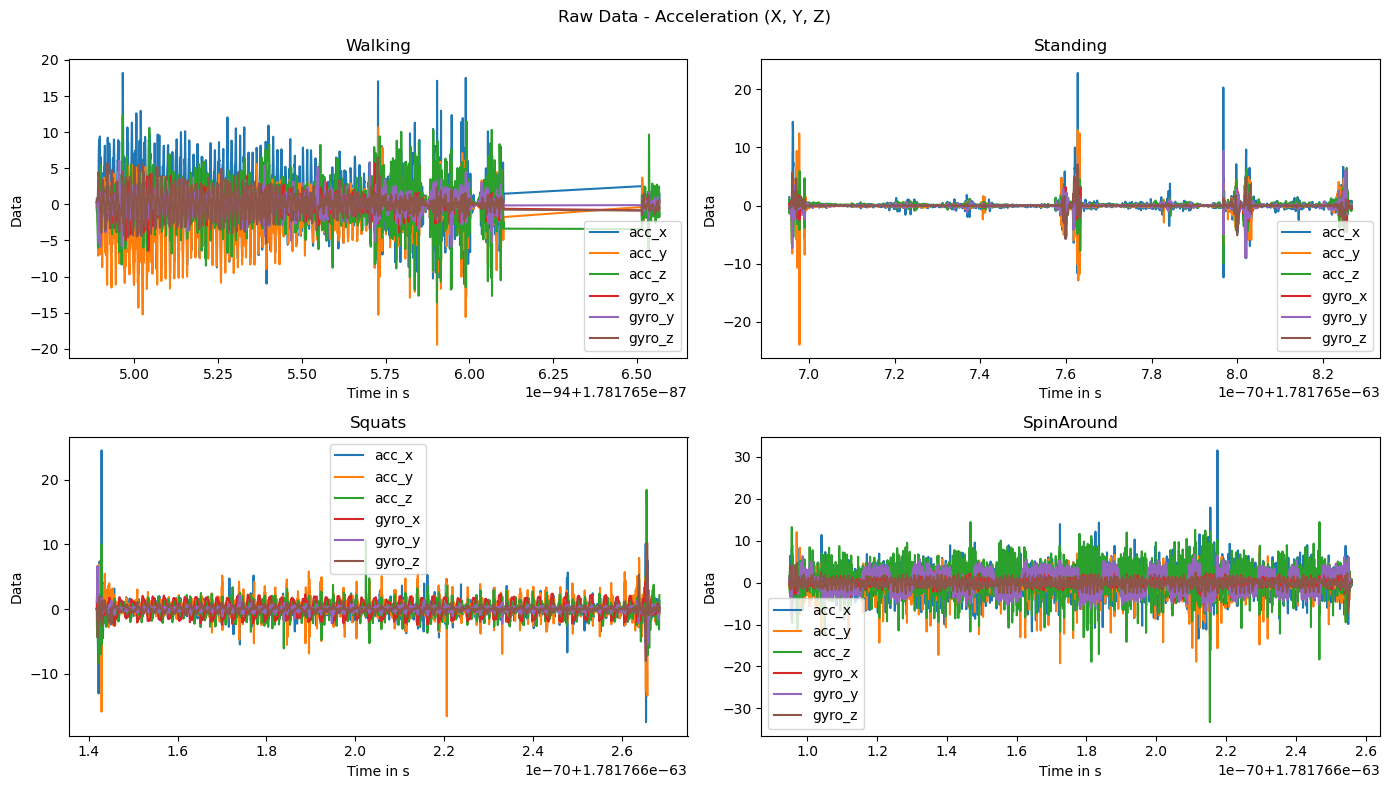

C:\Users\Dhanush VB\AppData\Local\Temp\ipykernel_10780\3656377244.py:45: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


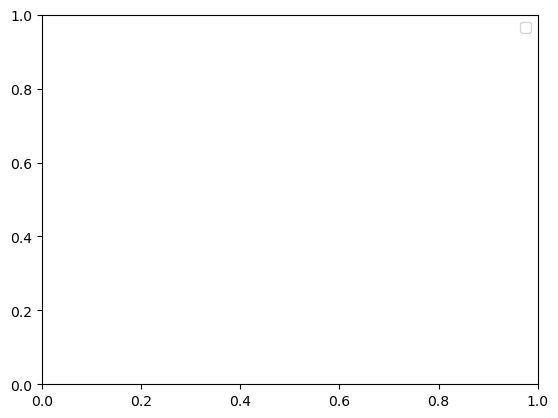

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

def plot_activity(df: pd.DataFrame, activity: str, sensor: str, acc_or_gyr_flag = "acc"):
    """Plots X, Y, and Z of one sensor over time."""
    # TODO: compute time in seconds (timestamp_ms - timestamp_ms[0]) / 1000
    time_in_s = df["timestamp_ms"]/1000
    # TODO: plot acc_x, acc_y, acc_z or gyro_x, gyro_y, gyro_z
    
    if ACTIVITIES[activity] == 1:
        m = 0
        n = 0
    elif ACTIVITIES[activity] == 2:
        m = 0
        n = 1
    elif ACTIVITIES[activity] == 3:
        m = 1
        n = 0
    elif ACTIVITIES[activity] == 4:
        m = 1
        n = 1

    axes[m][n].plot(time_in_s, df[sensor],label=sensor)  
    axes[m][n].set_ylabel('Data')
    axes[m][n].set_xlabel('Time in s')
    axes[m][n].set_title(activity)
    axes[m][n].legend()

    

    pass


i = 0
for activity in ACTIVITIES:
    for s in SENSOR_COLS:
        plot_activity(raw[activity], activity, s)
    i += 1

fig.suptitle("Raw Data - Acceleration (X, Y, Z)")

# TODO: create one subplot for each activity

plt.tight_layout()
plt.show()
plt.legend()


---
## Task 2 – Preprocessing

### 2a) Handle Missing Values

Check whether the data contains missing values (`NaN`) and handle them. If you were changing values, print helpful output.

**Hints:**
- `df.isnull().sum()` shows the number of missing values per column
- `df.interpolate(method='linear')` fills gaps with linear interpolation
- `df.dropna()` removes rows with missing values (only if there are few gaps)

**Example Output**

```code
Walking: 0 missing values
Standing: 0 missing values
Squats: 0 missing values
SpinAround: 0 missing values
```


In [ ]:
for activity, df in raw.items():
    missing = 0; # replace with real calculation here
    print(f"{activity}: {missing} missing values")

# TODO: handle missing values for all activities
# Store the cleaned DataFrames back in raw


---
## Task 3 – Feature Engineering (Sliding Window)

### Idea
A single measurement, such as `acc_x = 0.23`, contains little information about the activity.
A short time segment, such as 2.56 seconds, is needed to make the movement recognizable.

With the **sliding-window method**, we split the time series into overlapping windows
and compute statistical features for each window.

```
|-- Window 1 --|                     Window size = 64 Samples (2.56 s @ 25 Hz)
        |-- Window 2 --|             Overlap = 32 Samples (50%)
                |-- Window 3 --|
```

### 3a) Implement the sliding-window function

**Hints:**
- `WINDOW_SIZE = 64`, `STEP_SIZE = 32` (50% Overlap)
- Iterate with a `for` loop: `for start in range(0, len(data) - WINDOW_SIZE, STEP_SIZE)`
- Extract each Window: `window = data[start : start + WINDOW_SIZE]`


In [ ]:
WINDOW_SIZE = 64   # Samples (= 2.56 seconds at 25 Hz)
STEP_SIZE   = 32   # 50% Overlap

def sliding_windows(data: np.ndarray) -> list[np.ndarray]:
    """Splits a 2D array (samples x features) into overlapping windows (64 x features).
    
    Returns:
        List of arrays, each with shape (WINDOW_SIZE, n_features)
    """
    windows = []
    # TODO: loop over all possible start positions
    # Hint: range(0, len(data) - WINDOW_SIZE + 1, STEP_SIZE)
    return windows


### 3a check) Verify the sliding-window function

Call the sliding-window function on one of the original activity recordings.
Print the dimensions of the result to verify that the function returns the expected number of windows and that each window contains `WINDOW_SIZE` samples and all sensor columns.


In [ ]:
activity = "Walking"
data = raw[activity][SENSOR_COLS].to_numpy()
print("Your original shape:", data.shape)

# TODO: create sliding windows from the original data
# TODO: print the number of windows
# TODO: print the shape of the first window


### 3b) Compute features per window

Compute the following features for each window and each of the six sensor axes:

| Feature | numpy function | Description |
|---|---|---|
| Mean | `np.mean()` | central tendency |
| Standard deviation | `np.std()` | spread |
| Minimum | `np.min()` | Smallest value |
| Maximum | `np.max()` | Largest value |

**Result:** 6 axes x 4 features = **24 features per window**

**Hints:**
- Apply the functions along `axis=0` (over time, not over axes)
- `np.concatenate([mean, std, min, max])` combines the feature vectors
- Feature names: `acc_x_mean`, `acc_x_std`, ... (useful for later analysis)


In [ ]:
# Nothing to implement here: this helper creates the expected feature names.
def build_feature_names() -> list[str]:
    """Creates a list with 24 feature names."""
    return [f"{col}_{stat}" for col in SENSOR_COLS for stat in ["mean", "std", "min", "max"]]

FEATURE_NAMES = build_feature_names()
print(f"{len(FEATURE_NAMES)} Features:", FEATURE_NAMES)


In [ ]:
# Now implement the function and keep the same feature order as FEATURE_NAMES.
def extract_features(window: np.ndarray) -> np.ndarray:
    """Computes statistical features for one window.
    
    Args:
        window: Array with shape (WINDOW_SIZE, 6)
    Returns:
        Feature vector of length 24
    """
    # TODO: compute mean, standard deviation, minimum, maximum for each feature and add it to the result

    return feature_vector


### 3c) Apply feature extraction to all activities


In [ ]:
def process_activity(df: pd.DataFrame) -> np.ndarray:
    """Applies sliding windows and feature extraction to one activity DataFrame.
    
    Returns:
        Array with shape (n_windows, 24)
    """
    data = df[SENSOR_COLS].to_numpy()
    # TODO: call sliding_windows
    # TODO: call extract_features for each window
    # TODO: stack the results into an array (np.vstack or np.array)
    pass


features = {}  # Dict: activity name -> feature array
for activity, df in raw.items():
    features[activity] = process_activity(df)
    print(f"{activity}: {features[activity].shape[0]} windows, {features[activity].shape[1]} features")


### 3d) Remove outlier windows after aggregation

Now remove suspicious **windows** from the aggregated feature data instead of deleting individual raw sensor samples.
This keeps the 25 Hz time series intact during windowing and avoids removing meaningful motion peaks before the features are computed.

We use one simple method here: the **z-score method**.
For each feature, the z-score tells us how many standard deviations a value is away from the mean.
A window is considered suspicious if at least one feature has `|z| > 3`.

**Hints:**
- Convert the feature matrix into a DataFrame with `FEATURE_NAMES`.
- Compute `mean` and `std` for each feature column.
- Calculate `z_scores = abs((value - mean) / std)`.
- Keep only rows where all feature z-scores are below the threshold.
- Apply this per activity so high-motion activities are not compared directly with low-motion activities.


In [ ]:
def remove_outlier_windows_zscore(feature_matrix: np.ndarray, threshold: float = 3.0) -> np.ndarray:
    """Removes suspicious feature windows from one activity using z-scores."""
    # TODO: convert feature_matrix to a DataFrame with FEATURE_NAMES
    # TODO: compute z-scores for every feature column
    # TODO: keep only windows where all absolute z-scores are below threshold
    # Return: feature_matrix without outlier windows
    pass


for activity in ACTIVITIES:
    before = len(features[activity])
    features[activity] = remove_outlier_windows_zscore(features[activity])
    after = len(features[activity])
    print(f"{activity}: {before - after} outlier windows removed ({before} -> {after} windows)")


---
## Task 4 - Label and combine the dataset

### 4a) Create labels

Create a label array for each activity and then combine all activities
into one shared dataset. Print the result for verification.

**Hints:**
- `np.ones(n) * label` creates an array with `n` entries of the value `label`
- `np.vstack([A, B, C])` stacks arrays vertically (more rows)
- `np.concatenate([a, b, c])` combines 1D arrays


In [ ]:
# TODO: create a label array for each activity
# Hint: ACTIVITIES maps activity names to numeric labels

X = None  # Feature matrix: (n_total, 24)
y = None  # Label vector:   (n_total,)

# TODO: combine all activities

print(f"Full dataset: {X.shape[0]} Windows, {X.shape[1]} Features")
print("Class distribution:")
for activity, label in ACTIVITIES.items():
    count = (y == label).sum()
    print(f"  {label} – {activity}: {count} Windows")


### 4b) Scale the feature matrix

The model will not directly see the raw sensor samples. It will see the extracted feature matrix `X`.
Therefore, scaling should be applied after feature engineering, so that features such as means, standard deviations, minima, and maxima are on comparable scales.

Different scalers are possible. A common choice is `StandardScaler`, which transforms each feature to mean `0` and standard deviation `1`. `MinMaxScaler` is another option if bounded values, for example between `0` and `1`, are desired. Choose an appropriate scaler and document your decision.

**Important:** Strictly speaking, in a real train/test workflow you should first split the data, fit the scaler only on `X_train`, and then use this fitted scaler to transform `X_train`, `X_test`, and later unseen data. In this lab we simplify the workflow and fit the scaler on the complete feature matrix. If the dataset is sufficiently large and representative, the scaling parameters estimated from the full dataset and from the training subset are usually very similar. Still, for a final model evaluation, the train-only fitting procedure is the correct approach. 


In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# TODO: choose an appropriate scaler and explain your choice
# Examples:
# scaler = StandardScaler()
# scaler = MinMaxScaler()

scaler = None

# TODO: fit the scaler on X and transform X
# TODO: Then verify by showing std, mean or min and max of each feature


### 4c) Save the fitted scaler

The scaler is part of the preprocessing pipeline. It learned the scaling parameters from the feature matrix.
If we later classify new, unseen sensor recordings, we must extract the same features and then use the same scaler again. Otherwise, the new data would be transformed differently from the data used to train the model.

We use `joblib` for saving. `joblib` is a small Python library that can store Python objects, such as fitted scikit-learn scalers or models, in a file and load them again later.


In [ ]:
# Nothing to implement here; review what this code stores and why.
import joblib  # used to save and load fitted scikit-learn objects

scaler_path = DATA_DIR / "feature_scaler.joblib"
joblib.dump(scaler, scaler_path)
print(f"Saved scaler to: {scaler_path}")


### 4d) Save dataset as CSV

Save the completed dataset as `feature_data.csv`.
Use the feature names as column headers and add the labels as the last column. Review the generated file on disk.

**Hints:**
- Create one Pandas table that contains all feature columns with column names.
- Add the activity label as an additional column.
- Store the table as a CSV file without writing the row index.


In [ ]:
# TODO: create a table from X and y and save it as CSV
output_path = DATA_DIR / "feature_data.csv"

print(f"Saved: {output_path}")


---
## Task 5 - Quick Check: Are the Features Promising for Learning?

Visualize two features as a scatter plot to see whether the activity classes show visible structure.
This is not a proof that a machine learning model will work, but it gives a first impression of whether the extracted features contain useful information.

**Comprehension question:**
Look at the scatter plot. Do the activities form clearly separated groups, partly overlapping groups, or one mixed cloud? Based on this plot, do the data look promising for training a classifier? Explain your answer briefly.

**Hints:**
- Try `acc_x_std` vs. `acc_z_std`, for example, because spread can differ by movement intensity.
- Use different colors for different activity labels.
- If the classes overlap strongly in this 2D plot, a classifier may still work because it can use all 24 features, not only the two shown here.


In [ ]:
# TODO: scatter plot two features, colored by activity
feature_x = "acc_x_std"
feature_y = "acc_z_std"

idx_x = FEATURE_NAMES.index(feature_x)
idx_y = FEATURE_NAMES.index(feature_y)

# TODO: plt.scatter(...) with legend


---
## Submission Artifacts

Prepare the following files and upload them on the eLearning page as your submission for this lab part:

- `Walking-001.csv`
- `Standing-001.csv`
- `Squats-001.csv`
- `SpinAround-001.csv`
- `feature_scaler.joblib`
- `feature_data.csv`

The raw activity files document your original recordings, the scaler file is needed to apply the same preprocessing later, and `feature_data.csv` is the final table used for training and analysis.


---
## Bonustask/Homework

For the bonus task, open the smartphone app settings and enable **Advanced Mode**. This unlocks four additional activities:

| Label | Activity |
|---|---|
| 5 | Boxing |
| 6 | Jumping |
| 7 | KneeRaise |
| 8 | WalkingBackward |

Record these additional activities as well. Then reuse the functions you already implemented in this notebook to process the larger activity set: load the CSV files, create sliding windows, extract features, remove suspicious windows, build the larger feature matrix, scale it, and save the new training artifacts.

Create the following additional output files and keep them for later use. They do **not** have to be uploaded for this lab submission:

- `large_feature_scaler.joblib`
- `large_feature_data.csv`

These files should contain the scaler and feature table for the extended dataset with all eight activities.
